# 03 Model Evaluation

Notebook นี้เปรียบเทียบ **ทุก models** (Baseline + Advanced) และวิเคราะห์:
- Metrics summary table
- Residual plots
- Feature Importance
- SHAP analysis (best model)


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

MODEL_DIR  = Path('../../models')
FIGURE_DIR = Path('../../reports/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'total_time_min'
RANDOM_STATE = 42
print('Libraries loaded')

Libraries loaded


## Load Data & Models

In [29]:
TARGET = 'total_time_min'

train_df = pd.read_csv('../../data/processed/train.csv', encoding='utf-8-sig')
test_df  = pd.read_csv('../../data/processed/test.csv',  encoding='utf-8-sig')

feature_cols = [c for c in train_df.columns if c != TARGET]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET]
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET]

# Drop non-numeric & fill missing
non_numeric = X_train.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f'Dropping non-numeric: {non_numeric}')
    X_train = X_train.drop(columns=non_numeric)
    X_test  = X_test.drop(columns=non_numeric)

X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

print(f'Features : {len(X_train.columns)}')
print(f'Train : X={X_train.shape}  y={y_train.shape}')
print(f'Test  : X={X_test.shape}   y={y_test.shape}')

Features : 27
Train : X=(17721, 27)  y=(17721,)
Test  : X=(4431, 27)   y=(4431,)


In [30]:
model_files = {
    'Baseline (best)' : MODEL_DIR / 'baseline_best_totaltime.joblib',
    'RF (tuned)'      : MODEL_DIR / 'rf_tuned_totaltime.joblib',
    'XGBoost (Optuna)': MODEL_DIR / 'xgb_tuned_totaltime.joblib',
    'LightGBM (Optuna)': MODEL_DIR / 'lgb_tuned_totaltime.joblib',
    'CatBoost (Optuna)': MODEL_DIR / 'cat_tuned_totaltime.joblib',
}

models = {}
for name, path in model_files.items():
    if path.exists():
        models[name] = joblib.load(path)
        print(f'Loaded : {name}')
    else:
        print(f'Missing: {name} ({path})')

Loaded : Baseline (best)
Loaded : RF (tuned)
Loaded : XGBoost (Optuna)
Loaded : LightGBM (Optuna)
Loaded : CatBoost (Optuna)


## Metrics Summary

In [31]:
def get_metrics(name, model, X_tr, y_tr, X_te, y_te):
    p_tr = model.predict(X_tr)
    p_te = model.predict(X_te)
    return {
        'Model'      : name,
        'Train MAE'  : round(mean_absolute_error(y_tr, p_tr), 2),
        'Test MAE'   : round(mean_absolute_error(y_te, p_te), 2),
        'Train RMSE' : round(np.sqrt(mean_squared_error(y_tr, p_tr)), 3),
        'Test RMSE'  : round(np.sqrt(mean_squared_error(y_te, p_te)), 2),
        'Train R²'   : round(r2_score(y_tr, p_tr), 2),
        'Test R²'    : round(r2_score(y_te, p_te), 2),
        'Overfit Gap': round(r2_score(y_tr, p_tr) - r2_score(y_te, p_te), 2),
    }

rows = [get_metrics(n, m, X_train, y_train, X_test, y_test) for n, m in models.items()]
metrics_df = pd.DataFrame(rows).sort_values('Test RMSE').reset_index(drop=True)

display_cols = ['Model', 'Test MAE', 'Test RMSE', 'Test R²', 'Train R²', 'Overfit Gap']
print(metrics_df[display_cols].to_string(index=False))

            Model  Test MAE  Test RMSE  Test R²  Train R²  Overfit Gap
LightGBM (Optuna)     11.54      14.65     0.56      0.68         0.12
 XGBoost (Optuna)     11.55      14.69     0.56      0.69         0.13
CatBoost (Optuna)     11.58      14.69     0.56      0.66         0.11
       RF (tuned)     11.74      14.85     0.55      0.90         0.35
  Baseline (best)     12.18      15.37     0.52      0.52         0.01


## Before vs After — Outlier Cleaning (Level 1 + Level 2)

เปรียบเทียบ metrics **ก่อน** และ **หลัง** เพิ่ม outlier rules:
- **Level 1A**: phase domain thresholds (wait/prepare/close)
- **Level 1B**: `loading_time_min` threshold แยกตาม CarType (4W/6W/10W/Trailer)
- **Level 2**: `total_time_min` > 200 min direct cut

| เงื่อนไข | Before | After |
|---|---|---|
| Train samples | 38,011 | 37,492 |
| Test samples | 9,503 | 9,374 |
| target std | 38.0 min | 34.1 min |
| target max | 506.9 min | 199.9 min |


=== Before vs After — Outlier Level 1 + Level 2 ===
            Model  RMSE Before  RMSE After  RMSE Delta  MAE Before  MAE After  MAE Delta  R2 Before  R2 After  R2 Delta
LightGBM (Optuna)        23.53       14.65       -8.88       17.14      11.54      -5.60       0.62      0.56     -0.06
 XGBoost (Optuna)        23.47       14.69       -8.78       17.10      11.55      -5.55       0.62      0.56     -0.06
CatBoost (Optuna)        23.46       14.69       -8.77       17.11      11.58      -5.53       0.62      0.56     -0.06
       RF (tuned)        24.00       14.85       -9.15       17.54      11.74      -5.80       0.60      0.55     -0.05
  Baseline (best)        27.08       15.37      -11.71       20.02      12.18      -7.84       0.49      0.52      0.03


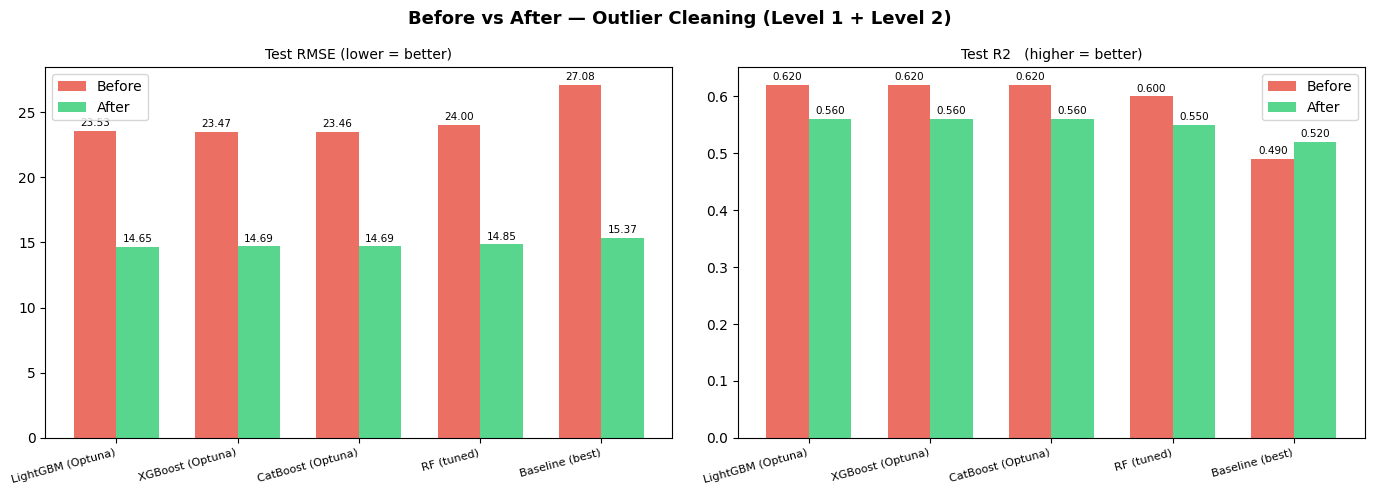

Figure saved: before_after_comparison.png


In [32]:
# ── Before vs After comparison (hardcoded baseline = pre-outlier-L1L2 run) ──
BEFORE = {
    'Baseline (best)' : {'RMSE': 27.08, 'MAE': 20.02, 'R2': 0.49},
    'RF (tuned)'       : {'RMSE': 24.00, 'MAE': 17.54, 'R2': 0.60},
    'XGBoost (Optuna)' : {'RMSE': 23.47, 'MAE': 17.10, 'R2': 0.62},
    'LightGBM (Optuna)': {'RMSE': 23.53, 'MAE': 17.14, 'R2': 0.62},
    'CatBoost (Optuna)': {'RMSE': 23.46, 'MAE': 17.11, 'R2': 0.62},
}

compare_rows = []
for _, row in metrics_df.iterrows():
    name = row['Model']
    bef  = BEFORE.get(name, {})
    compare_rows.append({
        'Model'        : name,
        'RMSE Before'  : bef.get('RMSE', '-'),
        'RMSE After'   : row['Test RMSE'],
        'RMSE Delta'   : round(row['Test RMSE'] - bef['RMSE'], 2) if bef else '-',
        'MAE Before'   : bef.get('MAE', '-'),
        'MAE After'    : row['Test MAE'],
        'MAE Delta'    : round(row['Test MAE'] - bef['MAE'], 2) if bef else '-',
        'R2 Before'    : bef.get('R2', '-'),
        'R2 After'     : row['Test R²'],
        'R2 Delta'     : round(row['Test R²'] - bef['R2'], 3) if bef else '-',
    })

compare_df = pd.DataFrame(compare_rows)
print('=== Before vs After — Outlier Level 1 + Level 2 ===')
print(compare_df.to_string(index=False))

# ── Plot: RMSE and R2 before/after ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Before vs After — Outlier Cleaning (Level 1 + Level 2)', fontsize=13, fontweight='bold')

model_names = compare_df['Model'].tolist()
x = np.arange(len(model_names))
w = 0.35

for ax, (metric_before, metric_after, title, fmt) in zip(axes, [
    ('RMSE Before', 'RMSE After', 'Test RMSE (lower = better)', '{:.2f}'),
    ('R2 Before',   'R2 After',   'Test R2   (higher = better)', '{:.3f}'),
]):
    b1 = ax.bar(x - w/2, compare_df[metric_before], w, label='Before', color='#e74c3c', alpha=0.8)
    b2 = ax.bar(x + w/2, compare_df[metric_after],  w, label='After',  color='#2ecc71', alpha=0.8)
    ax.bar_label(b1, fmt=fmt, padding=2, fontsize=7.5)
    ax.bar_label(b2, fmt=fmt, padding=2, fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.legend()

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'before_after_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved: before_after_comparison.png')


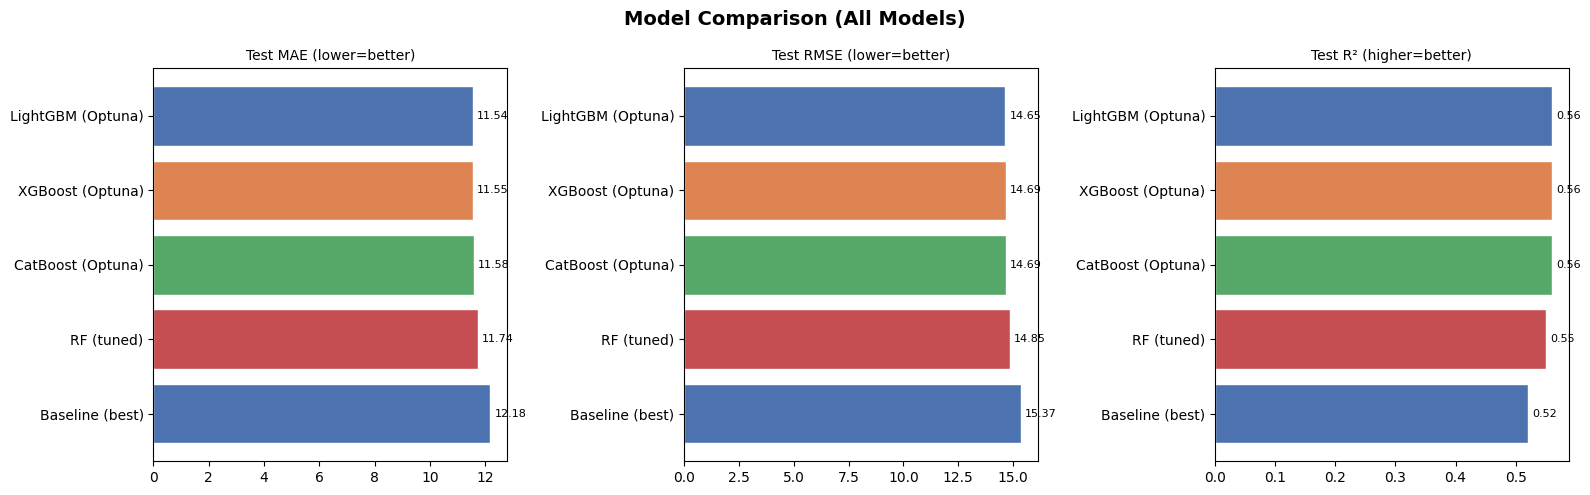

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison (All Models)', fontsize=14, fontweight='bold')
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (col, title) in zip(axes, [
    ('Test MAE',  'Test MAE (lower=better)'),
    ('Test RMSE', 'Test RMSE (lower=better)'),
    ('Test R²',   'Test R² (higher=better)'),
]):
    bars = ax.barh(metrics_df['Model'], metrics_df[col],
                   color=palette[:len(metrics_df)], edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'all_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Residual Analysis — Best Model

Best model : LightGBM (Optuna)


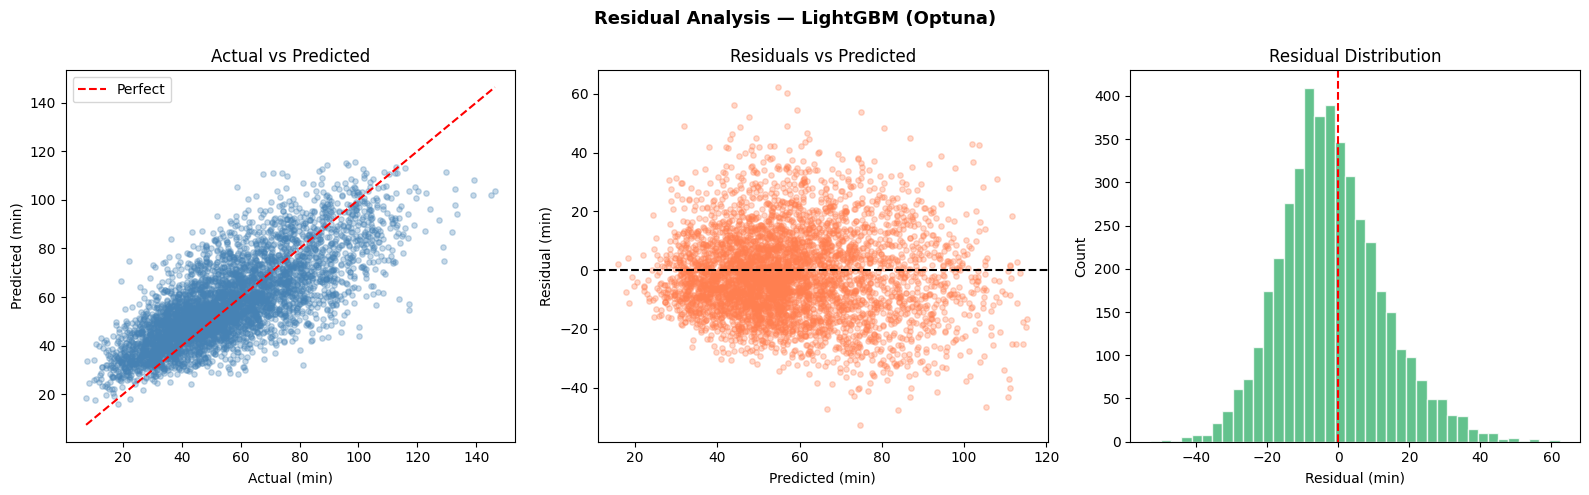

Mean residual : -1.7758 min
Std  residual : 14.5453 min


In [34]:
# เลือก best model
best_name  = metrics_df.iloc[0]['Model']
best_model = models[best_name]
print(f'Best model : {best_name}')

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Residual Analysis — {best_name}', fontsize=13, fontweight='bold')

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual (min)')
ax.set_ylabel('Predicted (min)')
ax.set_title('Actual vs Predicted')
ax.legend()

# Residuals vs Predicted
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.3, s=15, color='coral')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Predicted (min)')
ax.set_ylabel('Residual (min)')
ax.set_title('Residuals vs Predicted')

# Residual distribution
ax = axes[2]
ax.hist(residuals, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.set_xlabel('Residual (min)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean residual : {residuals.mean():.4f} min')
print(f'Std  residual : {residuals.std():.4f} min')

## Feature Importance — Best Model

Feature Importance -- LightGBM (Optuna)
                   Feature  Importance    Corr  CumSum
    rolling_avg_time_last5        2814  0.1120    2814
rolling_avg_cartype_last10        2442  0.4630    5256
      total_fitting_amount        2221  0.3340    7477
                TruckSeqNo        2198  0.0360    9675
          total_sap_amount        2168  0.6200   11843
         inter_arrival_min        2127 -0.0050   13970
  total_accessories_amount        1996  0.0950   15966
         total_tile_amount        1836  0.5830   17802
            car_type_x_sap        1729  0.6080   19531
             sap_per_group        1695  0.3850   21226
                      hour        1657  0.0140   22883
               queue_x_sap        1646  0.3130   24529
          PostLocationName        1442  0.0440   25971
                     month        1361 -0.0190   27332
               day_of_week         887 -0.0010   28219
             queue_loading         874  0.0490   29093
              queue_x_bay

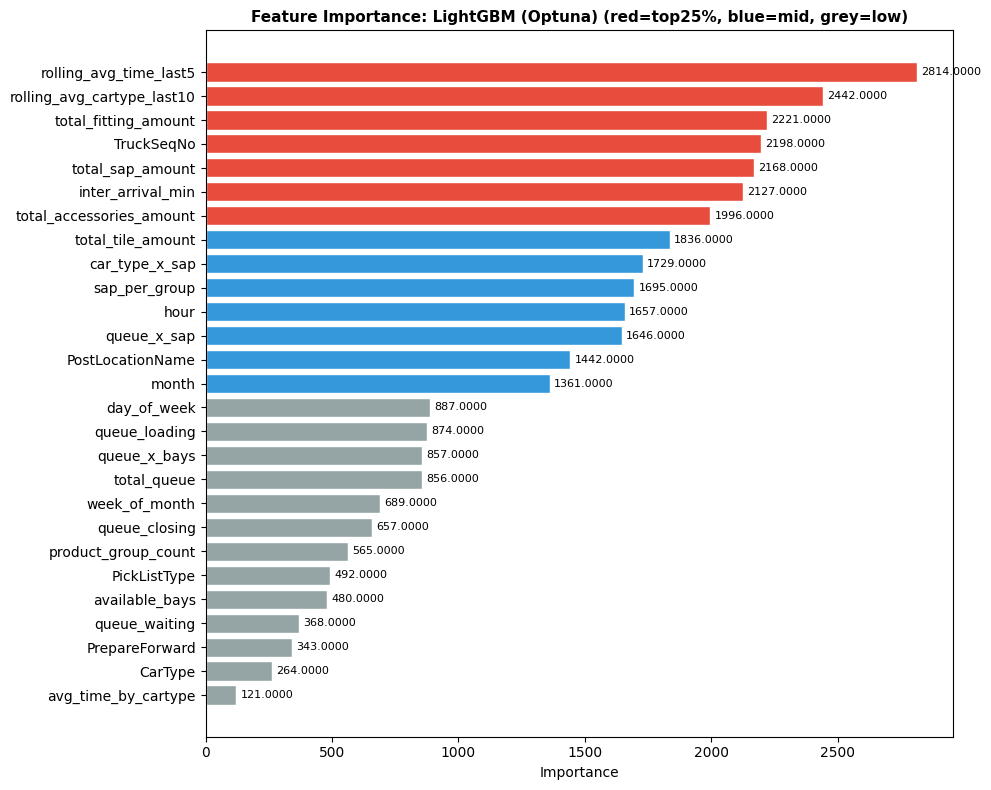

Figure saved


In [35]:
# Feature Importance -- Best Model only
if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
elif hasattr(best_model, 'get_feature_importance'):
    imp = best_model.get_feature_importance()
else:
    imp = None

if imp is not None:
    fi_all = pd.DataFrame({
        'Feature'    : X_train.columns,
        'Importance' : imp,
        'Corr'       : [round(float(X_train[c].corr(y_train)), 3) for c in X_train.columns],
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    fi_all['CumSum'] = fi_all['Importance'].cumsum().round(4)

    print(f'Feature Importance -- {best_name}')
    print(fi_all[['Feature', 'Importance', 'Corr', 'CumSum']].to_string(
        index=False, float_format=lambda x: f'{x:.4f}'))

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#e74c3c' if v >= fi_all['Importance'].quantile(0.75) else
              '#3498db' if v >= fi_all['Importance'].quantile(0.50) else '#95a5a6'
              for v in fi_all['Importance']]
    bars = ax.barh(fi_all['Feature'][::-1], fi_all['Importance'][::-1],
                   color=colors[::-1], edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importance: ' + best_name + ' (red=top25%, blue=mid, grey=low)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / 'feature_importance_best.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Figure saved')
else:
    print(f'{best_name} does not support feature_importances_')
    fi_all = pd.DataFrame(columns=['Feature', 'Importance', 'Corr', 'CumSum'])


## SHAP Analysis — Best Model

ใช้ SHAP เพื่อ interpret model — ว่า feature ไหนมีผลต่อการ predict มากแค่ไหน

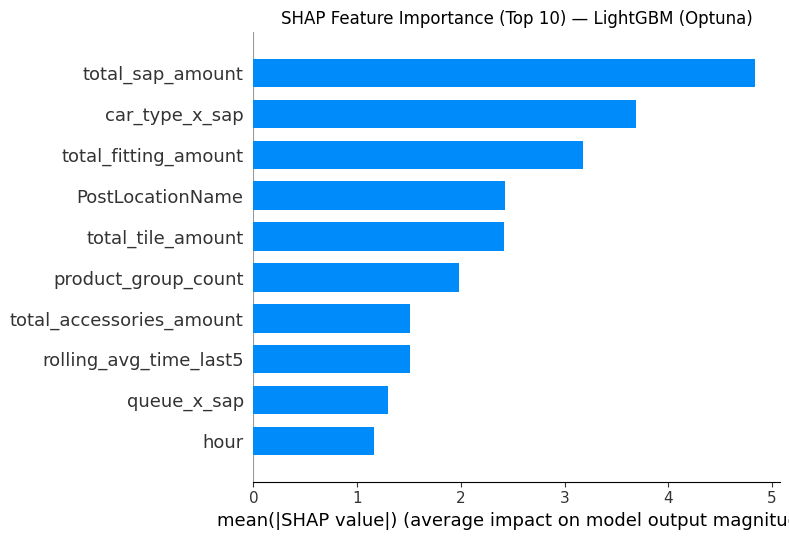

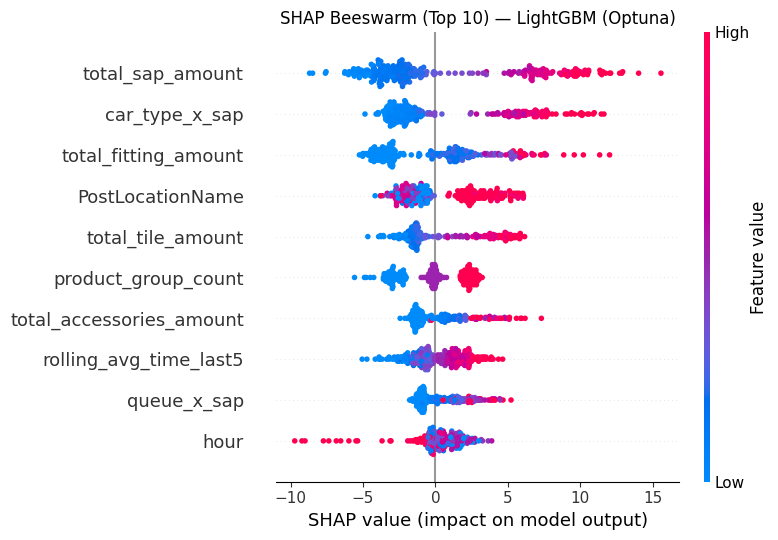

SHAP analysis done ✓


In [36]:
try:
    import shap
    shap.initjs()

    # ใช้ TreeExplainer สำหรับ tree models
    explainer = shap.TreeExplainer(best_model)
    
    # Sample 300 rows เพื่อความเร็ว
    X_sample = X_test.sample(min(300, len(X_test)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot (Bar) - แสดงแค่ Top 10
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=10, show=False)
    plt.title(f'SHAP Feature Importance (Top 10) — {best_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'shap_summary_bar.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Beeswarm plot - แสดงแค่ Top 10
    fig, ax = plt.subplots(figsize=(10, 8)) # แนะนำให้สร้าง figure ใหม่ก่อนพลอตเพื่อป้องกันกราฟซ้อนกัน
    shap.summary_plot(shap_values, X_sample, max_display=10, show=False)
    plt.title(f'SHAP Beeswarm (Top 10) — {best_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'shap_beeswarm.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('SHAP analysis done ✓')

except ImportError:
    print('shap not installed. Run: pip install shap')
except Exception as e:
    print(f'SHAP error (model may not support TreeExplainer): {e}')

## Error Analysis: Where Does the Model Fail?

=== Error Analysis — LightGBM (Optuna) ===
Test samples : 4,431

Error distribution:
count    4431.00
mean       11.54
std         9.03
min         0.01
25%         4.55
50%         9.42
75%        16.40
max        62.28
Name: abs_error, dtype: float64

Error buckets:
  0-5 min      : 1210 rows  ( 27.3%)
  5-10 min     : 1112 rows  ( 25.1%)
  10-15 min    :  820 rows  ( 18.5%)
  15-30 min    : 1090 rows  ( 24.6%)
  >30 min      :  199 rows  (  4.5%)

Error <= 10 min : 52.4%  (เป้าหมาย: สูง)
Error > 30 min  : 4.5%  (เป้าหมาย: ต่ำ)


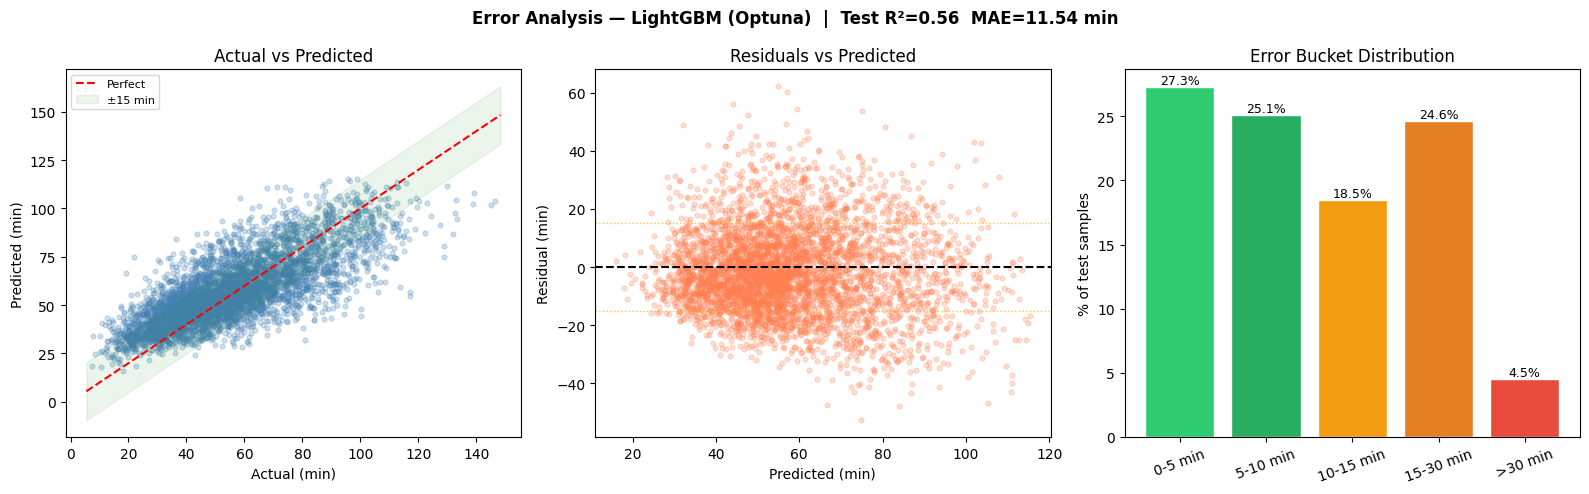


Top 10 worst predictions:
      actual  predicted  abs_error  pct_error
645   117.12      54.84      62.28       53.2
2450  117.30      57.02      60.28       51.4
655   100.28      44.15      56.13       56.0
292   113.72      59.36      54.36       47.8
3804  128.90      75.05      53.85       41.8
2609   22.08      74.78      52.70      238.7
1368  100.13      47.82      52.31       52.2
1995  106.05      56.87      49.18       46.4
1119   81.00      32.02      48.98       60.5
2050   94.23      45.63      48.60       51.6

Top 10 best predictions:
      actual  predicted  abs_error  pct_error
269    43.88      43.87       0.01        0.0
870    56.53      56.52       0.01        0.0
267    42.45      42.46       0.01        0.0
1287   59.47      59.46       0.01        0.0
804    47.78      47.80       0.02        0.0
2930   36.65      36.68       0.03        0.1
3328   62.75      62.78       0.03        0.0
3308   83.80      83.77       0.03        0.0
448    61.48      61.51    

In [37]:
best_name  = metrics_df.iloc[0]['Model']
best_model = models[best_name]
y_pred     = best_model.predict(X_test)

y_pred_s = pd.Series(y_pred, index=y_test.index)
err_df = pd.DataFrame({
    'actual'   : y_test,
    'predicted': y_pred_s,
    'abs_error': (y_test - y_pred_s).abs(),
    'residual' : y_test - y_pred_s,
})
err_df['pct_error'] = (err_df['abs_error'] / err_df['actual'] * 100).round(1)

# Error buckets
buckets = [0, 5, 10, 15, 30, np.inf]
labels  = ['0-5 min', '5-10 min', '10-15 min', '15-30 min', '>30 min']
err_df['bucket'] = pd.cut(err_df['abs_error'], bins=buckets, labels=labels)
bucket_summary = err_df['bucket'].value_counts().reindex(labels)
bucket_pct     = (bucket_summary / len(err_df) * 100).round(1)

print(f'=== Error Analysis — {best_name} ===')
print(f'Test samples : {len(err_df):,}')
print()
print('Error distribution:')
print(err_df['abs_error'].describe().round(2))
print()
print('Error buckets:')
for lbl, cnt, pct in zip(labels, bucket_summary, bucket_pct):
    print(f'  {lbl:<12} : {cnt:>4} rows  ({pct:>5.1f}%)')

print()
good_pct  = bucket_pct.iloc[0] + bucket_pct.iloc[1]
print(f'Error <= 10 min : {good_pct:.1f}%  (เป้าหมาย: สูง)')
print(f'Error > 30 min  : {bucket_pct.iloc[4]:.1f}%  (เป้าหมาย: ต่ำ)')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Error Analysis — {best_name}  |  Test R²={metrics_df.iloc[0]["Test R²"]:.2f}  MAE={metrics_df.iloc[0]["Test MAE"]:.2f} min',
             fontsize=12, fontweight='bold')

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.25, s=12, color='steelblue')
lim = [min(y_test.min(), y_pred.min())-2, max(y_test.max(), y_pred.max())+2]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax.fill_between(lim, [l-15 for l in lim], [l+15 for l in lim], alpha=0.08, color='green', label='±15 min')
ax.set_xlabel('Actual (min)'); ax.set_ylabel('Predicted (min)')
ax.set_title('Actual vs Predicted'); ax.legend(fontsize=8)

# Residuals vs Predicted
ax = axes[1]
ax.scatter(y_pred, err_df['residual'], alpha=0.25, s=12, color='coral')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.axhline(15, color='orange', lw=1, ls=':', alpha=0.7)
ax.axhline(-15, color='orange', lw=1, ls=':', alpha=0.7)
ax.set_xlabel('Predicted (min)'); ax.set_ylabel('Residual (min)')
ax.set_title('Residuals vs Predicted')

# Error bucket bar
ax = axes[2]
colors_b = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c']
bars = ax.bar(labels, bucket_pct, color=colors_b, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', fontsize=9)
ax.set_ylabel('% of test samples')
ax.set_title('Error Bucket Distribution')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'error_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 10 worst predictions:')
worst = err_df.nlargest(10, 'abs_error')[['actual','predicted','abs_error','pct_error']]
print(worst.round(2).to_string())


print('\nTop 10 best predictions:')
best = err_df.nsmallest(100, 'abs_error')[['actual','predicted','abs_error','pct_error']]
print(best.round(2).to_string())

## Final Report

In [38]:
best_row   = metrics_df.iloc[0]
dummy_rmse = 24.395   # DummyRegressor mean baseline (ข้อมูลก่อน clean)

# ── Before vs After reference ────────────────────────────────────────────────
BEFORE_BEST_RMSE = 23.46   # CatBoost ก่อน outlier L1+L2
BEFORE_BEST_R2   = 0.62
BEFORE_WITHIN_10 = 40.3
BEFORE_WITHIN_15 = 56.5
BEFORE_OVER_30   = 15.5

R2_COL = 'Test R²'   # ชื่อ column จริงใน metrics_df

print('=' * 65)
print('  FINAL MODEL EVALUATION REPORT — total_time_min')
print('=' * 65)
print(f'  Data     : {len(X_train):,} train  /  {len(X_test):,} test samples')
print(f'  Features : {X_train.shape[1]}')
print(f'  Target   : {TARGET}  (mean={y_test.mean():.1f} min, std={y_test.std():.1f} min)')
print()
print('  All Models (sorted by Test RMSE):')
for _, row in metrics_df.iterrows():
    marker = ' <-- BEST' if row['Model'] == best_row['Model'] else ''
    print(f'    {row["Model"]:<22}  RMSE={row["Test RMSE"]:>6.2f}  R2={row[R2_COL]:.3f}  '
          f'MAE={row["Test MAE"]:>6.2f}  Gap={row["Overfit Gap"]:+.2f}{marker}')
print()
print(f'  Improvement vs Dummy baseline : RMSE {dummy_rmse:.2f} -> {best_row["Test RMSE"]:.2f}  '
      f'({best_row["Test RMSE"] - dummy_rmse:+.2f})')
print()

# ── Error buckets ────────────────────────────────────────────────────────────
y_pred_final = best_model.predict(X_test)
abs_err = np.abs(y_test.values - y_pred_final)
bucket_labels = ['<=5 min', '5-10 min', '10-15 min', '15-30 min', '>30 min']
bucket_bins   = [0, 5, 10, 15, 30, np.inf]
bucket_pct = [
    round(((abs_err > lo) & (abs_err <= hi)).sum() / len(abs_err) * 100, 1)
    for lo, hi in zip(bucket_bins, bucket_bins[1:])
]

within_10 = bucket_pct[0] + bucket_pct[1]
within_15 = within_10 + bucket_pct[2]
over_30   = bucket_pct[4]

print('  Prediction accuracy (error buckets):')
for lbl, pct in zip(bucket_labels, bucket_pct):
    bar = '#' * int(pct / 2)
    print(f'    {lbl:<12}: {pct:>5.1f}%  {bar}')

best_r2 = best_row[R2_COL]
print()
print('  ── Before vs After (Outlier L1 + L2) ──────────────────────')
print(f'  Best RMSE  : {BEFORE_BEST_RMSE:.2f}  ->  {best_row["Test RMSE"]:.2f}  '
      f'({best_row["Test RMSE"] - BEFORE_BEST_RMSE:+.2f})')
print(f'  Best R2    : {BEFORE_BEST_R2:.3f}  ->  {best_r2:.3f}  '
      f'({best_r2 - BEFORE_BEST_R2:+.3f})')
print(f'  +-10 min   : {BEFORE_WITHIN_10:.1f}%  ->  {within_10:.1f}%  '
      f'({within_10 - BEFORE_WITHIN_10:+.1f}%)')
print(f'  +-15 min   : {BEFORE_WITHIN_15:.1f}%  ->  {within_15:.1f}%  '
      f'({within_15 - BEFORE_WITHIN_15:+.1f}%)')
print(f'  >30 min    : {BEFORE_OVER_30:.1f}%  ->  {over_30:.1f}%  '
      f'({over_30 - BEFORE_OVER_30:+.1f}%)')
print()
print('  Top features (avg importance, excl. RF):')
for _, row in fi_all.head(7).iterrows():
    print(f'    {row["Feature"]:<32}  {row["Importance"]:.4f}  (corr={row["Corr"]:+.2f})')
print()
print('  Outputs:')
print('    Figures -> reports/figures/')
print('    Models  -> models/')
print('=' * 65)

try:
    metrics_df.to_csv(MODEL_DIR / 'final_metrics_totaltime.csv', index=False)
    print('  Saved: models/final_metrics_totaltime.csv')
except PermissionError:
    alt = MODEL_DIR / 'final_metrics_totaltime_new.csv'
    metrics_df.to_csv(alt, index=False)
    print(f'  Saved (fallback): {alt.name}  (original file was locked)')


  FINAL MODEL EVALUATION REPORT — total_time_min
  Data     : 17,721 train  /  4,431 test samples
  Features : 27
  Target   : total_time_min  (mean=55.9 min, std=22.1 min)

  All Models (sorted by Test RMSE):
    LightGBM (Optuna)       RMSE= 14.65  R2=0.560  MAE= 11.54  Gap=+0.12 <-- BEST
    XGBoost (Optuna)        RMSE= 14.69  R2=0.560  MAE= 11.55  Gap=+0.13
    CatBoost (Optuna)       RMSE= 14.69  R2=0.560  MAE= 11.58  Gap=+0.11
    RF (tuned)              RMSE= 14.85  R2=0.550  MAE= 11.74  Gap=+0.35
    Baseline (best)         RMSE= 15.37  R2=0.520  MAE= 12.18  Gap=+0.01

  Improvement vs Dummy baseline : RMSE 24.39 -> 14.65  (-9.74)

  Prediction accuracy (error buckets):
    <=5 min     :  27.3%  #############
    5-10 min    :  25.1%  ############
    10-15 min   :  18.5%  #########
    15-30 min   :  24.6%  ############
    >30 min     :   4.5%  ##

  ── Before vs After (Outlier L1 + L2) ──────────────────────
  Best RMSE  : 23.46  ->  14.65  (-8.81)
  Best R2    : 0.620  -> 